Remove 20% of your data and save it as test_set and the other 80% as training_set.

In [1]:
import pandas as pd
# import pandas

In [2]:
# load breast cancer dataset
cancer_data = pd.read_csv('/home/jovyan/work/midtermaters/data.csv')
#subset cancer_data df for select columns
cancersubs = cancer_data[["id","diagnosis", "radius_mean", "texture_mean", "smoothness_mean", "compactness_mean"]]
cdf = cancer_data.copy() #cdf - new copy of og dataframe
# print the data types of each column in df
cdf.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [3]:
#using the subset df, we subset cdf to select only 4 features
cdfsub = cancersubs[["radius_mean", "texture_mean", "smoothness_mean", "compactness_mean"]]
stddev = cdfsub.std() #calculate standard deviation of 4 features
print(stddev) #printing out values

radius_mean         3.524049
texture_mean        4.301036
smoothness_mean     0.014064
compactness_mean    0.052813
dtype: float64


In [4]:
# Define function to apply z-score normalization
def mean_time_series(x):
     return (x-x.mean())/x.std()

#save list of the column names for 4 features we want to normalize
x = ["radius_mean", "texture_mean", "smoothness_mean", "compactness_mean"]
for _ in x: # loop through each feature to create a column name
    new_name = _ + "_normalized" 
    cdf[new_name] = cdfsub[_].transform(mean_time_series) #apply normalization function to original column and store as new col
    std = cdf[new_name].std() #calculate std dev for the four normalized columns
    print(f"{new_name}:{std}") #print column + std dev values; formatted with f-strings
    

cdf.head() #display first few lines of df with normalized feature columns

radius_mean_normalized:0.9999999999999999
texture_mean_normalized:1.0000000000000002
smoothness_mean_normalized:0.9999999999999998
compactness_mean_normalized:1.0000000000000004


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,radius_mean_normalized,texture_mean_normalized,smoothness_mean_normalized,compactness_mean_normalized
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,0.6656,0.7119,0.2654,0.4601,0.11890,NaN,1.096100,-2.071512,1.567087,3.280628
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,0.1866,0.2416,0.1860,0.2750,0.08902,NaN,1.828212,-0.353322,-0.826235,-0.486643
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,0.4245,0.4504,0.2430,0.3613,0.08758,NaN,1.578499,0.455786,0.941382,1.052000
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,0.8663,0.6869,0.2575,0.6638,0.17300,NaN,-0.768233,0.253509,3.280667,3.399917
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,0.2050,0.4000,0.1625,0.2364,0.07678,NaN,1.748758,-1.150804,0.280125,0.538866


In [5]:
#import revelant libraries
import math
import statistics
from sklearn.model_selection import train_test_split #lib to split data points

In [6]:
X = cdf[["radius_mean_normalized", "texture_mean_normalized", "smoothness_mean_normalized", "compactness_mean_normalized"]]
#select normalized features from df to store as X 
cdf['Malignant'] = (cdf['diagnosis'] == 'M').astype(int) # astype convert diagnosis column to binary metric
#malignant = 1, benign = 0
y = cdf['Malignant'] #save binary converted data as y 

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

X_train

,radius_mean_normalized,texture_mean_normalized,smoothness_mean_normalized,compactness_mean_normalized
10,0.537083,0.918465,-1.016791,-0.712915
170,-0.512845,-1.604183,0.457883,-0.653838
407,-0.362450,0.483686,-1.482515,-0.401058
430,0.219267,0.753389,0.221110,2.237320
27,1.272034,0.223284,-0.139382,0.042774
...,...,...,...,...
37,-0.311372,-0.202195,-0.464322,-1.262592
415,-0.634864,0.437186,0.097391,-0.438170
458,-0.319885,1.357894,-0.900893,-1.015114
476,0.020632,0.288384,-0.501295,0.122300


Part 1: Random Forest
Build a Random Forest model using the training_set with the four different variables listed above.
• Try using at least 3 different values for the maximum number of features m. Which m gives the best performance (AUC)?
• Which is the most important variable? How do you know?
• Use test_set to calculate the AUC of the best model created using the training_set.


In [69]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from sklearn.metrics import roc_auc_score

In [9]:
# supress warnings
warnings.simplefilter('ignore')

#use the value m using the max_features option in RandomForestClassifier
features = [1,2,3,4]
#initializing an empty dictionary to store each feature's ROC_AUC_score
feature_results = {}
for i in features: #for loop through listed features; trains logistic regression with single feature
    rfc_model = RandomForestClassifier(max_features = i, max_depth = 3)
    rfc_model.fit(X_train, y_train)
    feature_results[i] = [roc_auc_score(y_train, rfc_model.predict_proba(X_train)[:,1])]
feature_results

{1: [0.9887306501547987],
 2: [0.9866047471620227],
 3: [0.9838493292053664],
 4: [0.9835603715170278]}

In [10]:
#test
brfc_model = RandomForestClassifier(max_features = 1, max_depth = 3)
brfc_model.fit(X_train, y_train)
feature_results["best model test"] = [roc_auc_score(y_test, brfc_model.predict_proba(X_test)[:,1])]

In [11]:
# write data into a dataframe for ploting purpose
data = {"importances": brfc_model.feature_importances_,
        "feature": X_test.columns}
data4plt = pd.DataFrame(data)
data4plt = data4plt.sort_values(by=['importances'], ascending=False)
data4plt.reset_index(drop=True)


,importances,feature
0,0.405974,radius_mean_normalized
1,0.316352,compactness_mean_normalized
2,0.143192,texture_mean_normalized
3,0.134483,smoothness_mean_normalized


Part 2: SVM Classification

Use SVM to classify the test_set based on the values from training_set.
• Try at least 3 different cost values (and maybe a different kernel). Which gives the best
result (AUC)? -- kernel matters more than cost value; kernel is the data transformation applied to the dataset -- kernel transforms data into higher-dimensional space that makes it easier to make linearly separable; the cost is the penalty for misclassifying something -- tolerate more mistakes if the cost value is low (low tolerance for mistakes) vs 

In [12]:
from sklearn.svm import SVC

In [13]:
kernels = ['linear', 'poly', 'rbf']

SVM_feature_results = {}
for k in kernels:
    for i in range(1,10): #for loop through listed features; trains logistic regression with single feature
        svm_model = SVC(C= i/99.0, kernel= k, probability = True)
        svm_model.fit(X_train, y_train)
        SVM_feature_results[i,k] = [roc_auc_score(y_test, svm_model.predict_proba(X_test)[:,1])]

SVM_feature_results


{(1, 'linear'): [0.9755291005291006],
 (2, 'linear'): [0.9794973544973544],
 (3, 'linear'): [0.9775132275132274],
 (4, 'linear'): [0.9771825396825398],
 (5, 'linear'): [0.9768518518518519],
 (6, 'linear'): [0.9775132275132274],
 (7, 'linear'): [0.9765211640211641],
 (8, 'linear'): [0.9771825396825398],
 (9, 'linear'): [0.9775132275132274],
 (1, 'poly'): [0.9751984126984127],
 (2, 'poly'): [0.9751984126984127],
 (3, 'poly'): [0.9732142857142858],
 (4, 'poly'): [0.9722222222222223],
 (5, 'poly'): [0.9715608465608466],
 (6, 'poly'): [0.9712301587301587],
 (7, 'poly'): [0.970568783068783],
 (8, 'poly'): [0.9699074074074074],
 (9, 'poly'): [0.970568783068783],
 (1, 'rbf'): [0.9682539682539683],
 (2, 'rbf'): [0.9682539682539683],
 (3, 'rbf'): [0.9702380952380952],
 (4, 'rbf'): [0.9715608465608465],
 (5, 'rbf'): [0.9728835978835979],
 (6, 'rbf'): [0.9735449735449735],
 (7, 'rbf'): [0.9738756613756614],
 (8, 'rbf'): [0.9738756613756614],
 (9, 'rbf'): [0.974537037037037]}

In [16]:
frsvm_model = SVC(C= 0.002, kernel="linear", probability = True)
frsvm_model.fit(X_train, y_train)
svm_preds_results = frsvm_model.predict(X_test)

Draw a scatter plot using the two different variables radius_mean and texture_mean from test_set.
• Make two panels, one for random forest, another for SVM. Color the points based on what the points were predicted to be for RF/SVM using your optimal model. Shape the points based on the true value from the test_set. Do you see any pattern?

In [15]:
#creating copy of the original dataframe to add columns for the results and the true y-labels
res_df = X_test.copy() #copy
res_df #display dataframe

,radius_mean_normalized,texture_mean_normalized,smoothness_mean_normalized,compactness_mean_normalized
120,-0.771071,-1.969211,-0.187021,-0.709885
250,1.933205,0.992866,0.308567,1.065254
375,0.579648,-0.748575,0.173471,0.747149
99,0.083060,0.111683,0.082459,0.184785
455,-0.212055,2.657581,-0.278032,-0.569578
...,...,...,...,...
381,-0.876064,-1.013628,-1.172506,-0.635282
534,-0.898765,-0.388197,0.036242,-0.129154
448,0.114274,0.011707,-0.887384,-0.498762
205,0.281695,-0.606749,-0.540402,-0.160207


In [17]:
brfc_model_results = brfc_model.predict(X_test) # saving the predictions from test set using the best random forest classifier 

In [59]:
res_df["RF_points"] = brfc_model_results # storing the results from randomForest in another column of the copied df with the normalized features
res_df["SVM_points"] = svm_preds_results # storing rsults from SVM's predictions in another col
res_df["Y_test_points"] = y_test #storing true y-values to the df

,radius_mean_normalized,texture_mean_normalized,Y_test_points,Optimal_Model_Type,Point_preds
0,-0.771071,-1.969211,0,RF_points,0
1,1.933205,0.992866,1,RF_points,1
2,0.579648,-0.748575,0,RF_points,1
3,0.083060,0.111683,1,RF_points,0
4,-0.212055,2.657581,0,RF_points,0
...,...,...,...,...,...
223,-0.876064,-1.013628,0,SVM_points,0
224,-0.898765,-0.388197,0,SVM_points,0
225,0.114274,0.011707,0,SVM_points,0
226,0.281695,-0.606749,1,SVM_points,0


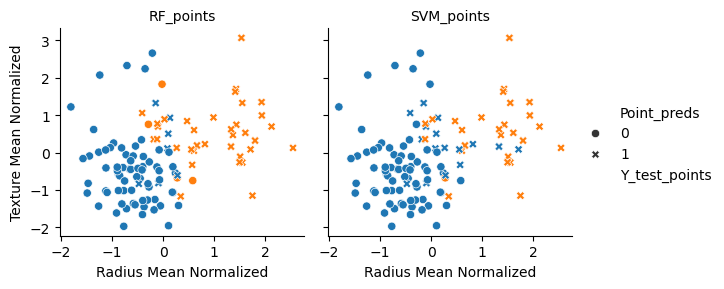

In [68]:
melted_resdf = pd.melt(res_df, id_vars = ["radius_mean_normalized","texture_mean_normalized", "Y_test_points"],
                       value_vars = ["RF_points", "SVM_points"],
                       var_name = "Optimal_Model_Type", value_name = "Point_preds")

melted_resdf #master df -- melted so that the columns for svm and randomforest predictions can be collated

#plotting the panels
g = sns.FacetGrid(melted_resdf, col = "Optimal_Model_Type")
g.map_dataframe(sns.scatterplot, x = "radius_mean_normalized", y = "texture_mean_normalized", style = "Y_test_points", hue = "Point_preds")
g.set_axis_labels("Radius Mean Normalized", "Texture Mean Normalized")
g.set_titles(col_template = "{col_name}")
g.add_legend()
plt.show()


In [ ]:
%matplotlib inline


hue - diagnosis = black/yellow
y-axis would be radius mean and texture mean
x-axis to classification predictions
distinguish test from training set - black squares; yellow circles = shows false positives or false negative

- if we can see strong correlation; proves 2 terms are the good enough



In [70]:
pwd

'/home/jovyan/work/midtermaters/Homework 4'